This notebook contains a complete fine-tuning workflow, including data preparation, model training, evaluation, and result analysis. This uses DINOv2 backbone and triplet loss with semi hard mining. The notebook is compatible with Google Colab and can be executed directly in the browser.



In [ ]:
#Needed to connect to collab with GPU
import torch

# Check if a GPU is available
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Connected to GPU device: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    print("GPU not available, using CPU instead.")


Connected to GPU device: NVIDIA A100-SXM4-40GB


In [ ]:
#To see Gpu version
import torch

if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))
else:
    print("No GPU detected.")

GPU Name: NVIDIA A100-SXM4-40GB


In [ ]:
from google.colab import drive
drive.flush_and_unmount()   # cleanly unmount old session
drive.mount('/content/drive', force_remount=True)


Drive not mounted, so nothing to flush and unmount.
Mounted at /content/drive


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os
import random
from tqdm.notebook import tqdm


In [ ]:
'''
Loads the image.
Converts it to RGB (ensures consistency).
Applies any specified transformations.
Returns a tuple (image_tensor, label).

'''

from torch.utils.data import Dataset
from PIL import Image
import os

class InShopDataset(Dataset):
    def __init__(self, root_dir, partition_file, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []

        with open(partition_file, 'r') as f:
            lines = f.readlines()[2:]  # skip header lines
            for line in lines:
                parts = line.strip().split()
                if len(parts) == 3:
                    img_path, label, partition = parts
                    if partition == 'train':
                        self.image_paths.append(os.path.join(root_dir, img_path))
                        self.labels.append(label)
                # skip malformed lines silently
                else:
                    continue

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        label = self.labels[idx]
        return img, label

    def __len__(self):
        return len(self.image_paths)



In [ ]:
#Confirm the dataset is working
dataset = InShopDataset(
    root_dir = '/content/drive/MyDrive/Capstone_Project/In-Shop Clothes Retrieval/Anno/densepose',  # <- one level higher
    partition_file='/content/drive/MyDrive/Capstone_Project/In-Shop Clothes Retrieval/Eval/list_eval_partition.txt',
    transform=transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor()
    ])
)


print(f"Total training images: {len(dataset)}")
#img, label, path = dataset[0]
img, label = dataset[0]
print("Image shape:", img.shape, "Label:", label)


Total training images: 25882
Image shape: torch.Size([3, 224, 224]) Label: 0


In [ ]:
#DEBUGING OR EDA STEP: This is to see how many unique labels are if there are multiple images for same label so we can use triplet minning from collections import Counter

# --- Extract labels safely ---
if hasattr(dataset, "samples"):
    labels_str = [lbl for _, lbl in dataset.samples]
elif hasattr(dataset, "labels"):
    labels_str = dataset.labels
else:
    raise AttributeError("Your dataset object has neither 'samples' nor 'labels' attributes!")

# --- Convert to integer labels if needed ---
unique_labels = sorted(set(labels_str))
label_to_int = {lbl: i for i, lbl in enumerate(unique_labels)}
int_labels = [label_to_int[lbl] for lbl in labels_str]

# --- Dataset stats ---
print(f" Total images: {len(labels_str)}")
print(f" Unique classes: {len(unique_labels)}")

counts = Counter(int_labels)
multi = [c for c in counts.values() if c > 1]
print(f" Classes with >1 sample: {len(multi)}/{len(counts)} ({100*len(multi)/len(counts):.2f}%)")

# --- Show example few labels and counts ---
for lbl, cnt in list(counts.items())[:10]:
    print(f"Label {lbl}: {cnt} images")

# --- Quick visualization check (optional) ---
img, lbl = dataset[0]
print("Sample image shape:", img.shape, "| Label:", lbl)


✅ Total images: 25882
✅ Unique classes: 3997
✅ Classes with >1 sample: 3985/3997 (99.70%)
Label 0: 4 images
Label 1: 5 images
Label 2: 6 images
Label 3: 4 images
Label 4: 10 images
Label 5: 5 images
Label 6: 7 images
Label 7: 9 images
Label 8: 4 images
Label 9: 3 images
Sample image shape: torch.Size([3, 224, 224]) | Label: 0


Total images: 25882
✅ Unique classes: 3997
✅ Classes with >1 sample: 3985/3997 (99.70%)
Label 0: 4 images
Label 1: 5 images
Label 2: 6 images
Label 3: 4 images
Label 4: 10 images
Label 5: 5 images
Label 6: 7 images
Label 7: 9 images
Label 8: 4 images
Label 9: 3 images
Sample image shape: torch.Size([3, 224, 224]) | Label: 0

In [ ]:
pip install pytorch-metric-learning


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.8/127.8 kB 2.9 MB/s eta 0:00:00


In [ ]:
# ================================================================
#  Train DINOv2 + Online Triplet Mining (Train + Validation)
# ================================================================
import os, time, random
import numpy as np
from collections import defaultdict, Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import transforms
from PIL import Image
from tqdm import tqdm

from pytorch_metric_learning import losses, miners
from pytorch_metric_learning.samplers import MPerClassSampler

# Speed
torch.backends.cudnn.benchmark = True

# ---------------- Config ----------------
save_dir = "/content/drive/MyDrive/Capstone_Project/checkpoints_a100_dino_semihard_v2_II"
os.makedirs(save_dir, exist_ok=True)

num_epochs = 50
lr = 1e-4
patience = 7

# Class-balanced batch config
P = 24   # classes per batch
M = 4    # samples per class
BATCH = P * M

VAL_SPLIT_RATIO = 0.15
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ------------- Repro -------------
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
set_seed(42)

# ---------------- Model ----------------
class DinoEmbeddingNet(nn.Module):
    def __init__(self, backbone):
        super().__init__()
        self.backbone = backbone
        self.fc = nn.Linear(768, 128) #projection layer - domain adaptation part, to improve embbeddings, 128 - cosine similarity will afster

    def forward(self, x):
        out = self.backbone(x)
        if isinstance(out, dict) and "x_norm_clstoken" in out:
            x = out["x_norm_clstoken"]
        elif isinstance(out, torch.Tensor):
            if out.dim() == 3:
                x = out[:, 0, :]
            elif out.dim() == 2:
                x = out
            else:
                raise ValueError(f"Unexpected DINOv2 output shape: {out.shape}")
        else:
            raise TypeError(f"Unexpected DINOv2 output type: {type(out)}")
        x = self.fc(x)
        return F.normalize(x, dim=1)

# ---------------- Dataset ----------------
class InShopDataset(Dataset):
    def __init__(self, root_dir, partition_file, transform=None, split="train"):
        self.root_dir = root_dir
        self.transform = transform
        self.samples, self.labels = [], []

        with open(partition_file, "r") as f:
            lines = f.readlines()[2:]  # skip headers
            for line in lines:
                parts = line.strip().split()
                if len(parts) == 3:
                    img_rel, lbl, part = parts
                    if part == split:
                        self.samples.append((os.path.join(root_dir, img_rel), lbl))
                        self.labels.append(lbl)

        self.label_to_indices = defaultdict(list)
        for i, lbl in enumerate(self.labels):
            self.label_to_indices[lbl].append(i)

        self.unique_labels = list(self.label_to_indices.keys())
        self.label_to_int = {lbl: i for i, lbl in enumerate(self.unique_labels)}
        self.int_labels = [self.label_to_int[lbl] for lbl in self.labels]

    def __getitem__(self, idx):
        idx = int(idx)
        img_path, _ = self.samples[idx]
        try:
            img = Image.open(img_path).convert("RGB")
        except Exception:
            # fallback black image if any file is corrupt/missing
            img = Image.new("RGB", (392, 392), (0, 0, 0))
        if self.transform:
            img = self.transform(img)
        return img, int(self.int_labels[idx])

    def __len__(self):
        return len(self.samples)

# ---------------- Helpers ----------------
def build_pm_loader(dataset: InShopDataset, indices, P, M, num_workers=4):
    """
    Build a DataLoader that guarantees P classes and M images each using MPerClassSampler.
    Will filter to classes with >= M images in 'indices'. Returns (loader, used_P).
    """
    # Filter indices to classes that have >= M samples (within the provided index subset)
    sub_labels = [dataset.int_labels[i] for i in indices]
    counts = Counter(sub_labels)
    valid_classes = {c for c, cnt in counts.items() if cnt >= M}
    filtered_indices = [i for i in indices if dataset.int_labels[i] in valid_classes]
    filtered_labels = [dataset.int_labels[i] for i in filtered_indices]

    if len(filtered_indices) == 0 or len(valid_classes) == 0:
        raise RuntimeError("No valid classes with >= M samples found for sampler.")

    # Possibly shrink P if not enough classes for validation
    used_P = min(P, len(valid_classes))
    batch_size = used_P * M

    subset = Subset(dataset, filtered_indices)
    subset_labels = [dataset.int_labels[i] for i in filtered_indices]

    # Note: This MPerClassSampler version (labels, m, length_before_new_iter) works as a *sampler* (per-sample).
    # With batch_size set to (used_P * M) and drop_last=True, DataLoader batches align to P×M composition.
    sampler = MPerClassSampler(
        labels=subset_labels,
        m=M,
        length_before_new_iter=len(subset_labels),
    )

    loader = DataLoader(
        dataset=subset,
        batch_size=batch_size,
        sampler=sampler,
        shuffle=False,         # must be False when using sampler
        num_workers=num_workers,
        pin_memory=True,
        drop_last=True,        # keep batch composition consistent
    )

    return loader, used_P

# ---------------- Train ----------------
def train_fn():
    # Backbone
    backbone = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitb14_reg')
    for p in backbone.parameters():
        p.requires_grad = False
    for name, p in backbone.named_parameters():
        if any(f"blocks.{i}." in name for i in range(8, 12)) or "norm" in name or "head" in name:
            p.requires_grad = True

    model = DinoEmbeddingNet(backbone).to(device)
    print("✅ Model initialized with partial unfreezing")

    # Transforms (392 is multiple of 14 for ViT-B/14)
    train_tf = transforms.Compose([
        transforms.RandomResizedCrop(392, scale=(0.8, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(0.25, 0.25, 0.25, 0.1),
        transforms.ToTensor(),
        transforms.Normalize((0.485,0.456,0.406),(0.229,0.224,0.225))
    ])
    val_tf = transforms.Compose([
        transforms.Resize((392,392)),
        transforms.CenterCrop(392),
        transforms.ToTensor(),
        transforms.Normalize((0.485,0.456,0.406),(0.229,0.224,0.225))
    ])

    root = "/content/drive/MyDrive/Capstone_Project/In-Shop Clothes Retrieval/Anno/densepose"
    part = "/content/drive/MyDrive/Capstone_Project/In-Shop Clothes Retrieval/Eval/list_eval_partition.txt"

    # Datasets (both from 'train' partition; val is a random holdout)
    train_ds = InShopDataset(root, part, transform=train_tf, split="train")
    val_ds   = InShopDataset(root, part, transform=val_tf,   split="train")

    # Split indices for train/val
    all_idx = np.arange(len(train_ds))
    np.random.shuffle(all_idx)
    val_n = int(VAL_SPLIT_RATIO * len(all_idx))
    val_indices   = [int(i) for i in all_idx[:val_n]]
    train_indices = [int(i) for i in all_idx[val_n:]]

    # Build loaders with P×M composition
    train_loader, used_P_train = build_pm_loader(train_ds, train_indices, P=P, M=M, num_workers=4)

    # Validation: maybe fewer valid classes; auto-adjust P_val
    try:
        val_loader, used_P_val = build_pm_loader(val_ds, val_indices, P=P, M=M, num_workers=2)
    except RuntimeError:
        # Fallback: try smaller P for validation
        for Pv in [min(12, P), min(8, P), min(4, P)]:
            try:
                val_loader, used_P_val = build_pm_loader(val_ds, val_indices, P=Pv, M=M, num_workers=2)
                break
            except RuntimeError:
                val_loader, used_P_val = None, None
        if val_loader is None:
            raise RuntimeError("Validation split cannot form P×M batches. Consider reducing M or increasing val size.")

    print(f" Train: {len(train_loader.dataset)} (P={used_P_train}, M={M}) | "
          f"Val: {len(val_loader.dataset)} (P={used_P_val}, M={M})")

    # Optim/Mining/Loss
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.1, patience=3)
    miner = miners.TripletMarginMiner(margin=0.4, type_of_triplets="semihard")
    criterion = losses.TripletMarginLoss(margin=0.4)
    scaler = torch.amp.GradScaler("cuda")

    best_val = float("inf")
    patience_ctr = 0


    #--------Just for sanity check-----
    #--------------------------------
    #Check batch composition (P×M) and shapes
    def check_batch_composition(loader, name="train", max_batches=2):
      import torch
      print(f"\n[Sanity] Checking {name} loader …")
      for b, (imgs, labels) in enumerate(loader):
          print(f"  batch {b+1}: imgs={tuple(imgs.shape)}, dtype={imgs.dtype}")
          u, c = torch.unique(labels, return_counts=True)
          print(f"  unique classes={len(u.tolist())}, counts per class (first 10): {c.tolist()[:10]}")
          if (imgs.shape[-1] % 14) != 0 or (imgs.shape[-2] % 14) != 0:
              print("  ⚠️ Image H/W not multiple of 14 — adjust transforms (e.g., 392).")
          if b+1 >= max_batches:
              break


    #2) One-batch miner + loss (no training) This verifies the miner actually finds triplets and the loss is sane (>0 and finite).

    @torch.no_grad()
    def check_one_batch_loss(model, loader, device, miner, criterion):
        model.eval()
        imgs, labels = next(iter(loader))
        imgs, labels = imgs.to(device), labels.to(device)
        with torch.amp.autocast("cuda"):
            emb = model(imgs)
            triplets = miner(emb, labels)
            # Count triplets if tuple of (a,p,n)
            n_triplets = len(triplets[0]) if (isinstance(triplets, tuple) and len(triplets) == 3) else 0
            loss = criterion(emb, labels, triplets)
        print(f"[Sanity] One-batch {loader.__dict__.get('dataset', None).__class__.__name__}: "
              f"triplets={n_triplets}, loss={float(loss):.6f}")

    #3) One optimizer step (ensure gradients flow) This confirms that the graph is valid and nothing is frozen incorrectly.
    def check_one_optimizer_step(model, loader, device, miner, criterion, optimizer):
      model.train()
      imgs, labels = next(iter(loader))
      imgs, labels = imgs.to(device), labels.to(device)
      scaler = torch.amp.GradScaler("cuda")
      with torch.amp.autocast("cuda"):
          emb = model(imgs)
          triplets = miner(emb, labels)
          loss = criterion(emb, labels, triplets)
      optimizer.zero_grad(set_to_none=True)
      scaler.scale(loss).backward()
      scaler.step(optimizer)
      scaler.update()
      print(f"[Sanity] One optimizer step OK. Loss={float(loss):.6f}")

    #4. Tiny overfit test (optional, 15–60 sec)
    #Take a very small subset (e.g., P=4, M=4 → batch=16) and run 20–50 steps.
    #The loss should clearly go down. This proves training plumbing is correct.

    def build_tiny_loader(dataset, P=4, M=4, num_workers=2):
      # keep only classes with >=M
      from collections import Counter
      labels = dataset.int_labels
      counts = Counter(labels)
      valid = {c for c, n in counts.items() if n >= M}

      # collect up to P classes, first M indices each
      picked_idx = []
      per_class = {c: 0 for c in valid}
      for i, c in enumerate(labels):
          if c in valid and per_class[c] < M:
              picked_idx.append(i)
              per_class[c] += 1
          if len({lc for lc, cnt in per_class.items() if cnt == M}) >= P:
              break

      subset = Subset(dataset, picked_idx)
      subset_labels = [dataset.int_labels[i] for i in picked_idx]

      sampler = MPerClassSampler(subset_labels, m=M, length_before_new_iter=len(subset_labels))
      bs = P * M
      return DataLoader(subset, batch_size=bs, sampler=sampler, shuffle=False,
                        num_workers=num_workers, pin_memory=True, drop_last=True)

    def quick_overfit(model, device, miner, criterion, steps=30, lr=1e-4):
        tiny_loader = build_tiny_loader(model.train_dataset, P=4, M=4)  # attach train_dataset to model or pass in separately
        opt = optim.Adam(model.parameters(), lr=lr)
        scaler = torch.amp.GradScaler("cuda")
        model.train()
        losses = []
        it = iter(tiny_loader)
        for s in range(steps):
            try:
                imgs, labels = next(it)
            except StopIteration:
                it = iter(tiny_loader)
                imgs, labels = next(it)
            imgs, labels = imgs.to(device), labels.to(device)
            with torch.amp.autocast("cuda"):
                emb = model(imgs)
                t = miner(emb, labels)
                loss = criterion(emb, labels, t)

            opt.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()
            losses.append(float(loss))
            if (s+1) % 5 == 0:
                print(f"[Overfit] step {s+1}/{steps} loss={float(loss):.4f}")
        print(f"[Overfit] start={losses[0]:.4f}, end={losses[-1]:.4f}")

    #5) Quick validation pass (no training
    #Same as (2), but iterate a couple of batches to ensure the miner works on val too:
    @torch.no_grad()
    def walk_val_loss(model, val_loader, device, miner, criterion, max_batches=3):
        model.eval()
        total, n = 0.0, 0
        for b, (imgs, labels) in enumerate(val_loader):
            imgs, labels = imgs.to(device), labels.to(device)
            with torch.amp.autocast("cuda"):
                emb = model(imgs)
                triplets = miner(emb, labels)
                loss = criterion(emb, labels, triplets)
            total += float(loss); n += 1
            print(f"[Val walk] batch {b+1}: loss={float(loss):.4f}")
            if b+1 >= max_batches:
                break
        if n:
            print(f"[Val walk] avg over {n} batches: {total/n:.4f}")

    check_batch_composition(train_loader, "train")
    check_batch_composition(val_loader, "val")

    check_one_batch_loss(model, train_loader, device, miner, criterion)
    check_one_batch_loss(model, val_loader,   device, miner, criterion)

    check_one_optimizer_step(model, train_loader, device, miner, criterion, optimizer)
    walk_val_loss(model, val_loader, device, miner, criterion)
    # (optional) quick_overfit(...)


    #------- this above was for sanity check before running full training-----------------------

    # ---------- Training ----------
    for epoch in range(num_epochs):
        model.train()
        running = 0.0
        t0 = time.time()

        for step, (imgs, labels) in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")):
            imgs, labels = imgs.to(device), labels.to(device)

            with torch.amp.autocast("cuda"):
                emb = model(imgs)
                idxs = miner(emb, labels)     # indices tuple
                loss = criterion(emb, labels, idxs)

            optimizer.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running += loss.item()

            if (step + 1) % 100 == 0:
                print(f"  step {step+1}/{len(train_loader)} - loss {loss.item():.4f}")

        train_loss = running / max(1, len(train_loader))
        print(f" Epoch {epoch+1}: train_loss={train_loss:.4f} | time={(time.time()-t0)/60:.2f} min")

        # ---------- Validation ----------
        model.eval()
        val_running = 0.0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                with torch.amp.autocast("cuda"):
                    emb = model(imgs)
                    idxs = miner(emb, labels)
                    vloss = criterion(emb, labels, idxs)
                val_running += vloss.item()

        val_loss = val_running / max(1, len(val_loader))
        print(f"🔵 Epoch {epoch+1}: val_loss={val_loss:.4f}")
        scheduler.step(val_loss)

        # ---------- Checkpoints & Early stopping ----------
        torch.save(model.state_dict(), os.path.join(save_dir, f"epoch_{epoch+1}.pth"))

        if val_loss < best_val:
            best_val = val_loss
            patience_ctr = 0
            torch.save(model.state_dict(), os.path.join(save_dir, "best_model.pth"))
            print(f"🏆 Saved new best (val_loss={best_val:.4f})")
        else:
            patience_ctr += 1
            print(f"⏳ No improvement ({patience_ctr}/{patience})")
            if patience_ctr >= patience:
                print("Early stopping.")
                break

    print(" Training complete.")

# ---------------- Main ----------------
if __name__ == "__main__":
    train_fn()


Using device: cuda


Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


✅ Model initialized with partial unfreezing
📦 Train: 18499 (P=24, M=4) | Val: 708 (P=24, M=4)

[Sanity] Checking train loader …
  batch 1: imgs=(96, 3, 392, 392), dtype=torch.float32
  unique classes=24, counts per class (first 10): [4, 4, 4, 4, 4, 4, 4, 4, 4, 4]
  batch 2: imgs=(96, 3, 392, 392), dtype=torch.float32
  unique classes=24, counts per class (first 10): [4, 4, 4, 4, 4, 4, 4, 4, 4, 4]

[Sanity] Checking val loader …
  batch 1: imgs=(96, 3, 392, 392), dtype=torch.float32
  unique classes=24, counts per class (first 10): [4, 4, 4, 4, 4, 4, 4, 4, 4, 4]
  batch 2: imgs=(96, 3, 392, 392), dtype=torch.float32
  unique classes=24, counts per class (first 10): [4, 4, 4, 4, 4, 4, 4, 4, 4, 4]
[Sanity] One-batch Subset: triplets=14444, loss=0.194954
[Sanity] One-batch Subset: triplets=12838, loss=0.197533
[Sanity] One optimizer step OK. Loss=0.179836


/tmp/ipython-input-433114394.py:271: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:835.)
  print(f"[Sanity] One optimizer step OK. Loss={float(loss):.6f}")


[Val walk] batch 1: loss=0.1631
[Val walk] batch 2: loss=0.1817
[Val walk] batch 3: loss=0.1740
[Val walk] avg over 3 batches: 0.1729


...

Epoch 20/50:  89%|████████▉ | 100/112 [00:59<00:06,  1.77it/s]

  step 100/112 - loss 0.0869


Epoch 20/50: 100%|██████████| 112/112 [01:05<00:00,  1.71it/s]

✅ Epoch 20: train_loss=0.0909 | time=1.09 min


🔵 Epoch 20: val_loss=0.1304
⏳ No improvement (7/7)
🛑 Early stopping.
🎉 Training complete.


🔵 Epoch 8: val_loss=0.1315
🏆 Saved new best (val_loss=0.1315)
Epoch 9/50:  89%|████████▉ | 100/112 [01:15<00:14,  1.24s/it]  step 100/112 - loss 0.1004
Epoch 9/50: 100%|██████████| 112/112 [01:23<00:00,  1.34it/s]✅ Epoch 9: train_loss=0.1095 | time=1.39 min


In [ ]:
pip install faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.4/31.4 MB 62.2 MB/s eta 0:00:00


In [ ]:
# ================================================================
# RECALL In-Shop Retrieval: Embedding Cache + Recall@K + FAISS Search
# ================================================================

import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from tqdm import tqdm

# Optional: FAISS (CPU/GPU). If not installed, set USE_FAISS=False.
try:
    import faiss  # pip install faiss-gpu  (or faiss-cpu)
    USE_FAISS = True
except Exception:
    print(" FAISS not found. Continuing without FAISS.")
    USE_FAISS = False

torch.backends.cudnn.benchmark = True

# ---------- Paths (EDIT THESE) ----------
device   = torch.device("cuda" if torch.cuda.is_available() else "cpu")
save_dir = "/content/drive/MyDrive/Capstone_Project/checkpoints_a100_dino_semihard_v2_II"
root     = "/content/drive/MyDrive/Capstone_Project/In-Shop Clothes Retrieval/Anno/densepose"
part_file= "/content/drive/MyDrive/Capstone_Project/In-Shop Clothes Retrieval/Eval/list_eval_partition.txt"
best_ckpt= os.path.join(save_dir, "best_model.pth")

# ================================================================
# 1) Model (same head as training)
# ================================================================
class DinoEmbeddingNet(nn.Module):
    def __init__(self, backbone):
        super().__init__()
        self.backbone = backbone
        self.fc = nn.Linear(768, 128)

    def forward(self, x):
        out = self.backbone(x)
        if isinstance(out, dict) and "x_norm_clstoken" in out:
            x = out["x_norm_clstoken"]
        elif isinstance(out, torch.Tensor):
            if out.dim() == 3:
                x = out[:, 0, :]
            elif out.dim() == 2:
                x = out
            else:
                raise ValueError(f"Unexpected DINOv2 output shape: {out.shape}")
        x = self.fc(x)
        return F.normalize(x, dim=1)

def create_model(device):
    backbone = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitb14_reg')
    for p in backbone.parameters():
        p.requires_grad = False
    # match your training unfreezing (harmless at eval time)
    for name, p in backbone.named_parameters():
        if any(f"blocks.{i}." in name for i in range(8, 12)) or "norm" in name or "head" in name:
            p.requires_grad = True
    return DinoEmbeddingNet(backbone).to(device).eval()

# ================================================================
# 2) Eval Dataset (query / gallery)
# ================================================================
class InShopEvalDataset(Dataset):
    """
    Expects list_eval_partition.txt with 3 columns:
      <relative_image_path> <label_str> <split>
    split ∈ {"query", "gallery", "train"}  (we use query/gallery here)
    """
    def __init__(self, root_dir, partition_file, transform=None, split="query"):
        self.root_dir = root_dir
        self.transform = transform
        self.samples = []  # list of (abs_path, label_str)
        with open(partition_file, "r") as f:
            lines = f.readlines()[2:]  # skip headers
            for line in lines:
                parts = line.strip().split()
                if len(parts) == 3:
                    rel_path, lbl, part = parts
                    if part == split:
                        self.samples.append((os.path.join(root_dir, rel_path), lbl))

    def __getitem__(self, idx):
        path, lbl = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, lbl, path

    def __len__(self):
        return len(self.samples)

# ================================================================
# 3) Transforms, Loaders, Embedding Extraction
# ================================================================
eval_tf = transforms.Compose([
    transforms.Resize((392, 392)),  # multiple of patch size 14 for ViT-B/14
    transforms.CenterCrop(392),
    transforms.ToTensor(),
    transforms.Normalize((0.485,0.456,0.406),(0.229,0.224,0.225))
])

def make_eval_loaders(root_dir, partition_file, batch_size=128, num_workers=4):
    qds = InShopEvalDataset(root_dir, partition_file, transform=eval_tf, split="query")
    gds = InShopEvalDataset(root_dir, partition_file, transform=eval_tf, split="gallery")
    qloader = DataLoader(qds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
    gloader = DataLoader(gds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
    return qds, gds, qloader, gloader

@torch.no_grad()
def extract_embeddings(model, loader, device):
    model.eval()
    all_embs, all_labels, all_paths = [], [], []
    for imgs, lbls, paths in tqdm(loader, desc="Extracting", leave=False):
        imgs = imgs.to(device, non_blocking=True)
        embs = model(imgs)
        all_embs.append(embs.cpu())
        all_labels.extend(lbls)
        all_paths.extend(paths)
    all_embs = torch.cat(all_embs, dim=0)  # [N, D]
    return all_embs, all_labels, all_paths

# ================================================================
# 4) Cache to/from NPZ
# ================================================================
def save_embeds_npz(path, embs, labels, paths, dtype=np.float16):
    embs = embs.cpu().numpy().astype(dtype)
    labels = np.array(labels, dtype=object)
    paths = np.array(paths, dtype=object)
    np.savez_compressed(path, embs=embs, labels=labels, paths=paths)

def load_embeds_npz(path):
    d = np.load(path, allow_pickle=True)
    embs = torch.from_numpy(d["embs"]).float()
    labels = d["labels"].tolist()
    paths = d["paths"].tolist()
    return embs, labels, paths

# ================================================================
# 5) Recall@K (batched cosine by matmul)
# ================================================================
@torch.no_grad()
def recall_at_k(query_embs, query_labels, gallery_embs, gallery_labels, Ks=(1,5,10), batch_size=4096, device="cuda"):
    Ks = tuple(sorted(Ks))
    qN = query_embs.size(0)
    hits = {k: 0 for k in Ks}

    q_labels = np.array(query_labels)
    g_labels = np.array(gallery_labels)

    # normalize & move gallery once
    q_embs = F.normalize(query_embs, dim=1)
    g_embs = F.normalize(gallery_embs, dim=1).to(device, non_blocking=True)

    step = batch_size
    for s in tqdm(range(0, qN, step), desc="Recall@K", leave=False):
        e = min(s+step, qN)
        q = q_embs[s:e].to(device, non_blocking=True)   # [B, D]
        sim = q @ g_embs.t()                            # [B, G]
        maxK = max(Ks)
        _, idx = torch.topk(sim, k=maxK, dim=1, largest=True, sorted=True)  # [B, maxK]
        idx = idx.cpu().numpy()
        g_top = g_labels[idx]  # [B, maxK] of strings

        for i, qlbl in enumerate(q_labels[s:e]):
            for k in Ks:
                if qlbl in g_top[i, :k]:
                    hits[k] += 1

    return {k: hits[k] / qN for k in Ks}

# ================================================================
# 6) FAISS index (cosine via dot product on normalized vectors)
# ================================================================
def build_faiss_index(embs: torch.Tensor, use_gpu=True):
    """
    Expects L2-normalized embs [N, D].
    Uses inner-product (IP) which equals cosine similarity for normalized vectors.
    """
    if not USE_FAISS:
        raise RuntimeError("FAISS not available. Install faiss-gpu or faiss-cpu.")
    x = F.normalize(embs, dim=1).cpu().numpy().astype('float32')
    d = x.shape[1]
    index = faiss.IndexFlatIP(d)
    if use_gpu and faiss.get_num_gpus() > 0:
        res = faiss.StandardGpuResources()
        index = faiss.index_cpu_to_gpu(res, 0, index)
    index.add(x)
    return index

@torch.no_grad()
def recall_at_k_faiss(query_embs, query_labels, gallery_index, gallery_labels, Ks=(1,5,10), batch_size=4096):
    if not USE_FAISS:
        raise RuntimeError("FAISS not available.")
    Ks = tuple(sorted(Ks))
    qN = query_embs.size(0)
    hits = {k: 0 for k in Ks}

    q_labels = np.array(query_labels)
    g_labels = np.array(gallery_labels)
    maxK = max(Ks)

    q_embs = F.normalize(query_embs, dim=1).cpu().numpy().astype('float32')

    step = batch_size
    for s in tqdm(range(0, qN, step), desc="Recall@K (FAISS)", leave=False):
        e = min(s+step, qN)
        q = q_embs[s:e]
        sims, idx = gallery_index.search(q, maxK)  # idx: [B, maxK]
        g_top = g_labels[idx]                      # [B, maxK]

        for i, qlbl in enumerate(q_labels[s:e]):
            for k in Ks:
                if qlbl in g_top[i, :k]:
                    hits[k] += 1

    return {k: hits[k] / qN for k in Ks}

# ================================================================
# 7) Full pipeline
# ================================================================
def main():
    print(f"Using device: {device}")
    assert os.path.exists(best_ckpt), f"Checkpoint not found: {best_ckpt}"

    # Create model & load weights
    model = create_model(device)
    state = torch.load(best_ckpt, map_location=device)
    model.load_state_dict(state, strict=True)
    model.eval()
    print("✅ Loaded best_model.pth")

    # Extract (or load) embeddings
    cache_dir = os.path.join(save_dir, "emb_cache_best")
    os.makedirs(cache_dir, exist_ok=True)
    q_cache = os.path.join(cache_dir, "query_embeds.npz")
    g_cache = os.path.join(cache_dir, "gallery_embeds.npz")

    if os.path.exists(q_cache) and os.path.exists(g_cache):
        print("📦 Loading cached embeddings …")
        q_embs, q_labels, _ = load_embeds_npz(q_cache)
        g_embs, g_labels, _ = load_embeds_npz(g_cache)
    else:
        print("🔎 Extracting embeddings …")
        qds, gds, qloader, gloader = make_eval_loaders(root, part_file, batch_size=128, num_workers=4)
        print(f"Query images: {len(qds)} | Gallery images: {len(gds)}")
        q_embs, q_labels, q_paths = extract_embeddings(model, qloader, device)
        g_embs, g_labels, g_paths = extract_embeddings(model, gloader, device)
        # normalize and save
        q_embs = F.normalize(q_embs, dim=1)
        g_embs = F.normalize(g_embs, dim=1)
        save_embeds_npz(q_cache, q_embs, q_labels, q_paths)
        save_embeds_npz(g_cache, g_embs, g_labels, g_paths)
        print(f"✅ Saved caches to {cache_dir}")

    # --- Recall@K (batched matmul) ---
    rec = recall_at_k(q_embs, q_labels, g_embs, g_labels, Ks=(1,5,10), batch_size=4096, device=device)
    print("Recall@K (MatMul):", {k: f"{v*100:.2f}%" for k,v in rec.items()})

    # --- Recall@K with FAISS ---
    if USE_FAISS:
        print("⚙️ Building FAISS index over gallery …")
        index = build_faiss_index(g_embs, use_gpu=True)
        rec_f = recall_at_k_faiss(q_embs, q_labels, index, g_labels, Ks=(1,5,10), batch_size=4096)
        print("Recall@K (FAISS):", {k: f"{v*100:.2f}%" for k,v in rec_f.items()})
    else:
        print("⚠️ Skipping FAISS evaluation (library not available).")

# ================================================================
if __name__ == "__main__":
    main()


Using device: cuda


Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


✅ Loaded best_model.pth
🔎 Extracting embeddings …
Query images: 14218 | Gallery images: 12612


✅ Saved caches to /content/drive/MyDrive/Capstone_Project/checkpoints_a100_dino_semihard_v2_II/emb_cache_best


Recall@K (MatMul): {1: '85.56%', 5: '94.42%', 10: '96.46%'}
⚙️ Building FAISS index over gallery …


Recall@K (FAISS): {1: '85.56%', 5: '94.42%', 10: '96.46%'}


Loaded best_model.pth

- Extracting embeddings …
- Query images: 14218 | Gallery images: 12612
- Saved caches to /content/drive/MyDrive/Capstone_Project/checkpoints_a100_dino_semihard_v2_II/emb_cache_best
                                                       - Recall@K (MatMul): {1: '85.56%', 5: '94.42%', 10: '96.46%'}
- Building FAISS index over gallery …
                                                               Recall@K (FAISS): {1: '85.56%', 5: '94.42%', 10: '96.46%'}

In [ ]:
#This doesn’t save anything. It only loads two files that should already exist:
#each .npz have embeddings, label, path
import os, torch, numpy as np

def load_embeds_npz(path):
    data = np.load(path, allow_pickle=True)
    embs   = torch.from_numpy(data["embs"]).float()         # [N, D]
    labels = data["labels"].tolist()                        # list[str]
    paths  = data["paths"].tolist()                         # list[str]
    return embs, labels, paths

save_dir = "/content/drive/MyDrive/Capstone_Project/checkpoints_a100_dino_semihard_v2_II"
cache_dir = os.path.join(save_dir, "emb_cache_best")
q_cache = os.path.join(cache_dir, "query_embeds.npz")
g_cache = os.path.join(cache_dir, "gallery_embeds.npz")

q_embs, q_labels, q_paths = load_embeds_npz(q_cache)
g_embs, g_labels, g_paths = load_embeds_npz(g_cache)

print(q_embs.shape, len(q_labels))
print(g_embs.shape, len(g_labels))


torch.Size([14218, 128]) 14218
torch.Size([12612, 128]) 12612


In [ ]:
#build the faiss from saved .npz file and load when we start after disconnecting colab
'''
Load gallery embeddings from disk (no model run needed).
Normalize each embedding to unit length with F.normalize(..., dim=1).
Build a FAISS index for Inner Product similarity:
Attach stable IDs to every vector:
Why this matters: next session you can reload the index + metadata in milliseconds and start searching immediately, with no GPU and no re-embedding.

'''
import os, numpy as np, torch, faiss, torch.nn.functional as F

save_dir  = "/content/drive/MyDrive/Capstone_Project/checkpoints_a100_dino_semihard_v2_II"
cache_dir = os.path.join(save_dir, "emb_cache_best")
g_cache   = os.path.join(cache_dir, "gallery_embeds.npz")

def load_embeds_npz(path):
    data = np.load(path, allow_pickle=True)
    embs   = torch.from_numpy(data["embs"]).float()   # [N, D]
    labels = data["labels"].tolist()                  # list[str]
    paths  = data["paths"].tolist()                   # list[str]
    return embs, labels, paths

# 1) load gallery set
g_embs, g_labels, g_paths = load_embeds_npz(g_cache)

# 2) (re)normalize for cosine (safety)
g_embs = F.normalize(g_embs, dim=1)

# 3) build a cosine-similarity index (IP on unit vectors)
d = g_embs.shape[1]
cpu_index = faiss.IndexFlatIP(d)

# optional but recommended: keep your own IDs aligned with labels/paths
ids = np.arange(g_embs.shape[0], dtype=np.int64)
index = faiss.IndexIDMap2(cpu_index)
index.add_with_ids(g_embs.numpy().astype("float32", copy=False), ids)

# 4) persist index + metadata
faiss.write_index(index, os.path.join(cache_dir, "gallery.index"))
np.save(os.path.join(cache_dir, "gallery_ids.npy"),   ids)
np.save(os.path.join(cache_dir, "gallery_labels.npy"), np.array(g_labels, dtype=object))
np.save(os.path.join(cache_dir, "gallery_paths.npy"),  np.array(g_paths,  dtype=object))

print("✅ Saved FAISS index and metadata to", cache_dir)


✅ Saved FAISS index and metadata to /content/drive/MyDrive/Capstone_Project/checkpoints_a100_dino_semihard_v2_II/emb_cache_best


query: torch.Size([14218, 128]) gallery: torch.Size([12612, 128])


mAP: 72.85%
{1: '85.56%', 5: '94.42%', 10: '96.46%', 20: '97.64%', 50: '98.68%'}


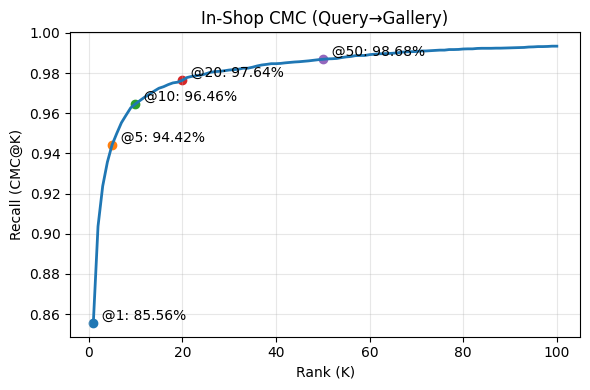

In [ ]:
#Check OVERFITTING using CMC curve
import os, numpy as np, torch
import torch.nn.functional as F

# ---- paths ----
save_dir  = "/content/drive/MyDrive/Capstone_Project/checkpoints_a100_dino_semihard_v2_II"
cache_dir = os.path.join(save_dir, "emb_cache_best")
q_cache   = os.path.join(cache_dir, "query_embeds.npz")
g_cache   = os.path.join(cache_dir, "gallery_embeds.npz")

def load_embeds_npz(path):
    d = np.load(path, allow_pickle=True)
    embs   = torch.from_numpy(d["embs"]).float()   # [N, D]
    labels = d["labels"].tolist()                  # list[str]
    paths  = d["paths"].tolist()                   # list[str]
    return embs, labels, paths

# 1) load
q_embs, q_labels, _ = load_embeds_npz(q_cache)
g_embs, g_labels, _ = load_embeds_npz(g_cache)

print("query:", q_embs.shape, "gallery:", g_embs.shape)

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm import tqdm

import numpy as np
import torch
import torch.nn.functional as F
from tqdm import tqdm

@torch.no_grad()
def compute_retrieval_metrics(q_embs, q_labels, g_embs, g_labels, max_rank=100, device=None):
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    # normalize for cosine similarity
    q = F.normalize(q_embs, dim=1).to(device)
    g = F.normalize(g_embs, dim=1).to(device)
    Nq, Ng = q.shape[0], g.shape[0]
    max_rank = min(max_rank, Ng)

    q_lbls = np.array(q_labels)
    g_lbls = np.array(g_labels)

    # successes_at_k[k] = #queries whose FIRST correct match rank <= k
    successes_at_k = np.zeros(max_rank, dtype=np.float64)
    APs = []

    step = 2048
    for s in tqdm(range(0, Nq, step), desc="Ranking", leave=False):
        e = min(s+step, Nq)
        sim = (q[s:e] @ g.t()).detach().cpu()               # [B, Ng]
        ranks = torch.argsort(sim, dim=1, descending=True).numpy()  # [B, Ng]
        g_sorted_lbls = g_lbls[ranks]

        for i in range(e - s):
            qlbl = q_lbls[s + i]
            rel = (g_sorted_lbls[i] == qlbl)                # bool array

            if not np.any(rel):
                APs.append(0.0)
                continue

            first_hit = np.argmax(rel)                      # first relevant rank (0-based)
            # mark success for all ranks >= first_hit
            successes_at_k[first_hit:] += 1

            # Average Precision for this query
            rel_idxs = np.where(rel)[0]
            precisions, retrieved, correct = [], 0, 0
            for r in range(rel_idxs[-1] + 1):
                retrieved += 1
                if rel[r]:
                    correct += 1
                    precisions.append(correct / retrieved)
            APs.append(np.mean(precisions) if precisions else 0.0)

    # ✅ CMC
    cmc = successes_at_k / float(Nq)
    mAP = float(np.mean(APs))
    return cmc, mAP

def plot_cmc(cmc, top_k=(1, 5, 10, 20, 50), title="CMC Curve"):
    ks = np.arange(1, len(cmc)+1)
    plt.figure(figsize=(6,4))
    plt.plot(ks, cmc, linewidth=2)
    plt.xlabel("Rank (K)")
    plt.ylabel("Recall (CMC@K)")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    # show markers at key K
    for k in top_k:
        if k <= len(cmc):
            plt.scatter([k], [cmc[k-1]])
            plt.text(k, cmc[k-1], f"  @{k}: {cmc[k-1]*100:.2f}%", va="bottom")
    plt.tight_layout()
    plt.show()

# ---------- RUN----------
# q_embs, q_labels, g_embs, g_labels must already be in memory (from your caches)
cmc, mAP = compute_retrieval_metrics(q_embs, q_labels, g_embs, g_labels, max_rank=100)
print(f"mAP: {mAP*100:.2f}%")
print({k: f"{cmc[k-1]*100:.2f}%" for k in [1,5,10,20,50] if k <= len(cmc)})

plot_cmc(cmc, top_k=(1,5,10,20,50), title="In-Shop CMC (Query→Gallery)")


The curve is monotonic and bounded in [0, 1].

CMC@1 85.56% matches your Recall@1 earlier — good consistency.

CMC@5 94.42%, @10 96.46%, @20 97.64%, @50 98.68% — classic fast-rising, saturating shape.

mAP 72.85% is reasonable given the strong CMC; it’s lower than CMC@1 (as expected) because it rewards ranking all matches, not just the first.

What this tells you

Retrieval quality is strong: most queries find the correct item within the top-5/10.

Since these numbers line up with your separate kNN/recall results below on the eval split, there’s no obvious sign of overfitting from the metrics you’ve shown.

**Train vs. Eval gap**

Compute kNN@1 on the training set embeddings as below code and compare to CMC@1 (Recall@1) on the eval set.

Rule of thumb: if the gap is small (e.g., ≤3–5 pp), overfitting is unlikely.

I have  ~85.56% on eval; if train kNN@1 is ~85.56% (not 99%+), that’s healthy.



-----
If i compute this Compute kNN@1 on the training set embeddings as below code and compare to CMC@1 (Recall@1) on the eval set. and i have same recall is it good

Yes—if train kNN@1 ≈ eval Recall@1, that’s a good sign you’re not overfitting. But a couple caveats:

How to interpret it

Good: Train kNN@1 and Eval Recall@1 are within ~3–5 percentage points (e.g., train 86–88%, eval 85.6%). That means the model performs similarly on data it saw vs. held-out data → little/no overfitting.

Suspicious: They’re exactly the same (to 2 decimals) or both are very high (e.g., 99%/99%). That often means

you accidentally evaluated on overlapping images (data leakage),

or you included the same image in the kNN gallery (self-match) for train.

If its Underfitting: Both will be low (e.g., 60%/60%). Model might just be weak.



------

In [ ]:
#Using KNN check for overfitting
import torch, numpy as np
import torch.nn.functional as F

# g_embs: [G, D] float tensor (normalized), g_labels: list[str], g_paths: list[str]
# q_embs: [Q, D] float tensor (normalized)

def knn_search(q_embs, g_embs, k=5, device="cuda"):
    q = F.normalize(q_embs, dim=1).to(device)
    g = F.normalize(g_embs, dim=1).to(device)
    sim = (q @ g.t())                               # [Q, G] cosine similarity
    topk_sim, topk_idx = torch.topk(sim, k=k, dim=1)
    return topk_sim.cpu(), topk_idx.cpu()           # tensors

def knn_classify(q_embs, g_embs, g_labels, k=5, weighted=True, device="cuda"):
    topk_sim, topk_idx = knn_search(q_embs, g_embs, k=k, device=device)
    g_labels_np = np.array(g_labels)

    preds = []
    for sims, idxs in zip(topk_sim, topk_idx):
        neigh_labels = g_labels_np[idxs.numpy()]    # [k]
        if weighted:
            # similarity-weighted vote
            weights = sims.numpy()
            score = {}
            for lab, w in zip(neigh_labels, weights):
                score[lab] = score.get(lab, 0.0) + float(w)
            pred = max(score.items(), key=lambda x: x[1])[0]
        else:
            # majority vote
            vals, counts = np.unique(neigh_labels, return_counts=True)
            pred = vals[np.argmax(counts)]
        preds.append(pred)
    return preds

def knn_top1_acc(q_embs, q_labels, g_embs, g_labels, k=1, device="cuda"):
    preds = knn_classify(q_embs, g_embs, g_labels, k=k, weighted=False, device=device)
    return (np.array(preds) == np.array(q_labels)).mean()

acc1 = knn_top1_acc(q_embs, q_labels, g_embs, g_labels, k=1)
print(f"kNN Top-1 Acc: {acc1*100:.2f}%")


kNN Top-1 Acc: 85.56%


In [ ]:
#Health check after re connecting colab
import os
print(os.path.exists(os.path.join(cache_dir, "gallery.index")))
print(os.path.exists(os.path.join(cache_dir, "gallery_labels.npy")))
print(os.path.exists(os.path.join(cache_dir, "gallery_paths.npy")))

import os, faiss, numpy as np

cache_dir = "/content/drive/MyDrive/Capstone_Project/checkpoints_a100_dino_semihard_v2_II/emb_cache_best"
index  = faiss.read_index(os.path.join(cache_dir, "gallery.index"))
ids    = np.load(os.path.join(cache_dir, "gallery_ids.npy"))
labels = np.load(os.path.join(cache_dir, "gallery_labels.npy"), allow_pickle=True).tolist()
paths  = np.load(os.path.join(cache_dir, "gallery_paths.npy"),  allow_pickle=True).tolist()
print("Index size:", index.ntotal, "labels:", len(labels), "paths:", len(paths))



In [ ]:
# ---- live search ----
'''
Run a live search for a new image (most common)

Embed one image with your model, then search the saved FAISS index.

'''
import os, faiss, numpy as np, torch, torch.nn as nn, torch.nn.functional as F
from PIL import Image
from torchvision import transforms

cache_dir = "/content/drive/MyDrive/Capstone_Project/checkpoints_a100_dino_semihard_v2_II/emb_cache_best"
index  = faiss.read_index(os.path.join(cache_dir, "gallery.index"))
labels = np.load(os.path.join(cache_dir, "gallery_labels.npy"), allow_pickle=True).tolist()
paths  = np.load(os.path.join(cache_dir, "gallery_paths.npy"),  allow_pickle=True).tolist()

# ---- load your encoder (same as training) ----
class DinoEmbeddingNet(nn.Module):
    def __init__(self, backbone):
        super().__init__()
        self.backbone = backbone
        self.fc = nn.Linear(768, 128)
    def forward(self, x):
        out = self.backbone(x)
        x = out["x_norm_clstoken"] if isinstance(out, dict) else (out[:,0,:] if out.dim()==3 else out)
        x = self.fc(x)
        return F.normalize(x, dim=1)

def create_model(device):
    backbone = torch.hub.load("facebookresearch/dinov2", "dinov2_vitb14_reg")
    for p in backbone.parameters(): p.requires_grad = False
    return DinoEmbeddingNet(backbone).to(device).eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model  = create_model(device)
state  = torch.load("/content/drive/MyDrive/Capstone_Project/checkpoints_a100_dino_semihard_v2_II/best_model.pth",
                    map_location=device)
ik = model.load_state_dict(state, strict=True)
model.eval()
print("missing:", ik.missing_keys, "unexpected:", ik.unexpected_keys)

# ---- same transforms as eval ----
eval_tf = transforms.Compose([
    transforms.Resize((392,392)),
    transforms.CenterCrop(392),
    transforms.ToTensor(),
    transforms.Normalize((0.485,0.456,0.406),(0.229,0.224,0.225)),
])

@torch.no_grad()
def embed_query(img_path):
    x = eval_tf(Image.open(img_path).convert("RGB")).unsqueeze(0).to(device) #resize + normalized if user upload different size
    e = model(x).cpu().numpy().astype("float32")  # [1, 128], L2-normalized
    return e

def search_topk(q_vec, k=5):
    sims, idxs = index.search(q_vec, k)
    return [(float(sims[0,i]), labels[idxs[0,i]], paths[idxs[0,i]]) for i in range(k)]

#image path here
query_img = paths[0]
print(query_img) #print to make sure it exists
q = embed_query(query_img)
for rank, (score, lbl, p) in enumerate(search_topk(q, k=5), 1):
    print(f"{rank}. {score:.3f}  {lbl}  {p}")


In [ ]:
#Metric.json and later we will have config.json and config.json will have appended metric.json
import os, json, datetime

bundle_dir = "/content/drive/MyDrive/Capstone_Project/checkpoints_a100_dino_semihard_v2_II/bundle_v1"
os.makedirs(bundle_dir, exist_ok=True)
metrics_path = os.path.join(bundle_dir, "metrics.json")

entry = {
    "created_utc": datetime.datetime.utcnow().isoformat()+"Z",
    "dataset": "In-Shop Clothes Retrieval",
    "split": "official query/gallery",
    "num_query": 14218,
    "num_gallery": 12612,
    "recall_at_k": {"1": 0.8556, "5": 0.9442, "10": 0.9646},
    "eval_method": "cosine (IP on unit vectors)",
    "faiss": {"used": True, "index": "IndexFlatIP"},
    "transform_fingerprint": "resize=392;crop=392;imagenet_meanstd",
    "seed": 42,
    "bundle_version": "1.0.0",
    "notes": "MatMul and FAISS matched"
}

if os.path.exists(metrics_path):
    data = json.load(open(metrics_path))
    assert isinstance(data, list)
    data.append(entry)
else:
    data = [entry]

with open(metrics_path, "w") as f:
    json.dump(data, f, indent=2)

print("metrics.json updated")


metrics.json updated


/tmp/ipython-input-1743472430.py:9: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "created_utc": datetime.datetime.utcnow().isoformat()+"Z",


In [ ]:
'''
Freeze a reproducible release (one-time)

Creates a new Bundle based on dateandtime to avoid overrwrite : weights (state_dict), FAISS CPU index + labels/paths, transform spec, metrics, config, env snapshot, checksums.

Version: model_v1/, index_v1/ etc. Never overwrite; always bump versions.

Sanity tests: self-match test; load-and-search test; checksum verify.
What this gives you:

A portable bundle folder you can zip, share, deploy.

config.json that nails backbone, head dim, transforms, and index paths.

checksums so you can verify integrity after copying.

A quick test so you know it loads after you reconnect.
model/weights.pt (your best_model.pth)
index/gallery.index, gallery_labels.npy, gallery_paths.npy
transforms/eval_transform.json
metrics.json (nice-to-have)
config.json (single source of truth)
Note:1. Keep all paths in config.json relative to the bundle root.
Note:2. Don’t assume /content/... anywhere in runtime code.

'''

import os, json, shutil, hashlib, datetime, platform, sys, numpy as np, torch, faiss

# ----- INPUTS: update only if your paths are different -----
SAVE_DIR  = "/content/drive/MyDrive/Capstone_Project/checkpoints_a100_dino_semihard_v2_II"
CACHE_DIR = os.path.join(SAVE_DIR, "emb_cache_best")
BEST_CKPT = os.path.join(SAVE_DIR, "best_model.pth")   # trained state_dict
BACKBONE  = "dinov2_vitb14_reg"
EMB_DIM   = 128
RESIZE    = 392
MEAN      = [0.485, 0.456, 0.406] #ImageNet RGB channel statistics (mean and std) most torchvision models—like DINOv2 ViT-B/14—expect.
STD       = [0.229, 0.224, 0.225]

# Required files you already created
REQUIRED = [
    BEST_CKPT,
    os.path.join(CACHE_DIR, "gallery.index"),
    os.path.join(CACHE_DIR, "gallery_labels.npy"),
    os.path.join(CACHE_DIR, "gallery_paths.npy"),
]
# Optional (include if they exist)
OPTIONAL = [
    os.path.join(CACHE_DIR, "gallery_ids.npy"),
    os.path.join(CACHE_DIR, "query_embeds.npz"),
    os.path.join(CACHE_DIR, "gallery_embeds.npz"),
]

# ----- OUTPUT: bundle folder with timestamp/version -----
ts = datetime.datetime.utcnow().strftime("%Y%m%dT%H%M%SZ") #based on timestamp it creates bundle so we never overwrite
BUNDLE = os.path.join(SAVE_DIR, f"bundle_v{ts}")
os.makedirs(BUNDLE, exist_ok=True)

def ensure_files(paths):
    missing = [p for p in paths if not os.path.exists(p)]
    if missing:
        raise FileNotFoundError("Missing required artifacts:\n" + "\n".join(missing))

def sha256(p, chunk=1<<20):
    h=hashlib.sha256()
    with open(p,'rb') as f:
        for b in iter(lambda:f.read(chunk), b''):
            h.update(b)
    return h.hexdigest()

# 1) sanity
ensure_files(REQUIRED)

# 2) model/
os.makedirs(os.path.join(BUNDLE,"model"), exist_ok=True)
state = torch.load(BEST_CKPT, map_location="cpu")

#This is to have cleaner unwrapped checkpoints to get weights easily
if isinstance(state, dict) and "state_dict" in state: state = state["state_dict"]
if isinstance(state, dict) and "model" in state and isinstance(state["model"], dict): state = state["model"]
# strip 'module.' if saved from DataParallel
if isinstance(state, dict) and len(state) and next(iter(state)).startswith("module."):
    state = {k.replace("module.", "", 1): v for k, v in state.items()}
# If your checkpoint is {"model": state_dict, ...}, unwrap it:
if isinstance(state, dict) and "state_dict" in state: state = state["state_dict"]
if isinstance(state, dict) and "model" in state and all(hasattr(v, "shape") for v in state["model"].values()):
    state = state["model"]

torch.save(state, os.path.join(BUNDLE,"model","weights.pt"))
json.dump({"backbone": BACKBONE, "embedding_dim": EMB_DIM}, open(os.path.join(BUNDLE,"model","arch.json"),"w"), indent=2)

# 3) transforms/
os.makedirs(os.path.join(BUNDLE,"transforms"), exist_ok=True)
json.dump({
    "resize": RESIZE,
    "center_crop": RESIZE,
    "normalize": {"mean": MEAN, "std": STD}
}, open(os.path.join(BUNDLE,"transforms","eval_transform.json"),"w"), indent=2)

# 4) index/
os.makedirs(os.path.join(BUNDLE,"index"), exist_ok=True)
for fname in ["gallery.index","gallery_labels.npy","gallery_paths.npy","gallery_ids.npy"]:
    src = os.path.join(CACHE_DIR, fname)
    if os.path.exists(src):
        shutil.copy2(src, os.path.join(BUNDLE,"index", fname))

# 5) cache/ (optional)
os.makedirs(os.path.join(BUNDLE,"cache"), exist_ok=True)
for src in OPTIONAL:
    if os.path.exists(src):
        shutil.copy2(src, os.path.join(BUNDLE,"cache", os.path.basename(src)))

# 6) config.json (single source of truth); this is run time path
#so relative paths resolve against the bundle root like "index/gallery.index" not against content/so it can run from anywhere
config = {
  "version": "1.0.0",
  "project": "inshop-retrieval",
  "created_utc": ts,
  "model": {"backbone": BACKBONE, "embedding_dim": EMB_DIM, "weights_relpath": "model/weights.pt", "freeze_backbone": True},
  "transforms": {"resize": RESIZE, "center_crop": RESIZE, "normalize": {"mean": MEAN, "std": STD}},
  "index": {
    "type": "faiss.IndexFlatIP",
    "dimension": EMB_DIM,
    "cpu_index_path": "index/gallery.index",
    "labels_path": "index/gallery_labels.npy",
    "paths_path":  "index/gallery_paths.npy",
    "ids_path":    "index/gallery_ids.npy"
  },
  "data": {"dataset": "In-Shop Clothes Retrieval"},
  "metrics_path": "metrics.json",  # config.json and metric.json will be different file but metric.json can be appended to config.json and metric like recall can be filled in runtime
  "serve": {"device": "auto", "top_k_default": 5, "exclude_self_match": True, "move_index_to_gpu": False}
}

#copy metric.json to same bundle
# after writing config.json
src_metrics = os.path.join(SAVE_DIR, "bundle_v1", "metrics.json")  # adjust if stored elsewhere
dst_metrics = os.path.join(BUNDLE, "metrics.json")
if os.path.exists(src_metrics):
    shutil.copy2(src_metrics, dst_metrics)
    print("copied metrics.json")
else:
    print("no metrics.json found to copy (optional)")

json.dump(config, open(os.path.join(BUNDLE,"config.json"),"w"), indent=2)

# 7) env snapshot
env_txt = f"""python: {sys.version.split()[0]}
platform: {platform.platform()}
torch: {getattr(torch, "__version__", "unknown")}
faiss: {getattr(faiss, "__version__", "unknown")}
cuda_available: {torch.cuda.is_available()}
"""
open(os.path.join(BUNDLE,"env.txt"),"w").write(env_txt)

# 8) README
open(os.path.join(BUNDLE,"README.md"),"w").write(
"""# Retrieval Bundle

Contents:
- model/weights.pt (state_dict), model/arch.json
- transforms/eval_transform.json
- index/gallery.index + labels/paths (and ids if present)
- cache/ (optional npz caches)
- config.json, env.txt, checksums.sha256

Load steps:
1) Build the model per model/arch.json; load weights.pt; model.eval().
2) Apply transforms/eval_transform.json to query images before encoding.
3) Read FAISS index at index/gallery.index; search with 128-D L2-normalized query embedding.
4) Map result indices to labels/paths via the .npy files.
"""
)

# 9) checksums
checks = []
for root, _, files in os.walk(BUNDLE):
    for fn in sorted(files):
        p = os.path.join(root, fn)
        rel = os.path.relpath(p, BUNDLE)
        checks.append(f"{sha256(p)}  {rel}")
open(os.path.join(BUNDLE,"checksums.sha256"),"w").write("\n".join(checks))

print(" Bundle created:", BUNDLE)


/tmp/ipython-input-1799435086.py:48: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  ts = datetime.datetime.utcnow().strftime("%Y%m%dT%H%M%SZ") #based on timestamp it creates bundle so we never overwrite


copied metrics.json
 Bundle created: /content/drive/MyDrive/Capstone_Project/checkpoints_a100_dino_semihard_v2_II/bundle_v20251105T005816Z


In [ ]:
#To see where config is:
import os, glob
BASE = "/content/drive/MyDrive/Capstone_Project/checkpoints_a100_dino_semihard_v2_II"
print("All configs:", glob.glob(os.path.join(BASE, "bundle_*", "config.json")))


All configs: ['/content/drive/MyDrive/Capstone_Project/checkpoints_a100_dino_semihard_v2_II/bundle_v20251103T224014Z/config.json', '/content/drive/MyDrive/Capstone_Project/checkpoints_a100_dino_semihard_v2_II/bundle_v20251103T234831Z/config.json']


In [ ]:
#This is to ensure above config and version state saved bundle works
#and assigns variable model, device, index, labels, paths.
#device is very important and we need to set before calling torch.load for both cpu, gpu and mps

import os, json, faiss, numpy as np, torch, torch.nn as nn, torch.nn.functional as F
from PIL import Image
from torchvision import transforms

BUNDLE = BUNDLE  # the path printed above

cfg = json.load(open(os.path.join(BUNDLE,"config.json")))
assert cfg["model"]["embedding_dim"] == cfg["index"]["dimension"]

# transforms
t = cfg["transforms"]
eval_tf = transforms.Compose([
    transforms.Resize((t["resize"], t["resize"])),
    transforms.CenterCrop(t["center_crop"]),
    transforms.ToTensor(),
    transforms.Normalize(t["normalize"]["mean"], t["normalize"]["std"]),
])

# Inference module: backbone + Linear(768→128) + L2 norm (definition must match your training head)
# inference model i will use during testing
#build the model(on same arch) → pick device → map_location=device → load_state_dict. Only skip this if you’re loading a pre-exported TorchScript/ONNX model.

class DinoEmbeddingNet(nn.Module):
    def __init__(self, backbone, head_dim):
        super().__init__()
        self.backbone = backbone
        self.fc = nn.Linear(768, head_dim) ## from fc.weight [128, 768]
    def forward(self, x):
        out = self.backbone(x)
        x = out["x_norm_clstoken"] if isinstance(out, dict) else (out[:,0,:] if out.dim()==3 else out)
        x = self.fc(x)
        return F.normalize(x, dim=1)

def create_model(device, backbone, head_dim):
    bb = torch.hub.load("facebookresearch/dinov2", backbone)
    for p in bb.parameters(): #not required but harmless
      p.requires_grad = False
    return DinoEmbeddingNet(bb, head_dim).to(device).eval()

#device pick vvi
if torch.cuda.is_available(): device = torch.device("cuda")
elif getattr(torch.backends, "mps", None) and torch.backends.mps.is_available(): device = torch.device("mps")
else: device = torch.device("cpu")

model  = create_model(device, cfg["model"]["backbone"], cfg["model"]["embedding_dim"])
state  = torch.load(os.path.join(BUNDLE, cfg["model"]["weights_relpath"]), map_location=device)
_ik = model.load_state_dict(state, strict=True); model.eval()

#Load FAISS + metadata
index  = faiss.read_index(os.path.join(BUNDLE, cfg["index"]["cpu_index_path"]))
labels = np.load(os.path.join(BUNDLE, cfg["index"]["labels_path"]), allow_pickle=True).tolist()
paths  = np.load(os.path.join(BUNDLE, cfg["index"]["paths_path"]),  allow_pickle=True).tolist()

# self-search sanity
vec0 = index.reconstruct(0).reshape(1,-1).astype("float32")
sims, idxs = index.search(vec0, 1)
print("Self-search OK:", idxs[0,0] == 0, "index size:", index.ntotal, "labels:", len(labels))


Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


Self-search OK: True index size: 12612 labels: 12612


In [ ]:
#optional
'''
encoder.torchscript.pt:
Creating a deployable artifact of the model (e.g., encoder.torchscript.pt or encoder.onnx) so it can run fast, portable inference without the original training code.
Portability: Load the model in a different process, container, or even C++ (TorchScript) / ONNX Runtime, without Python source or repo.


When is it needed:
You’re building a backend/API that should start fast and be stable across releases.
You want to ship the model to another team, platform, or language (C++/Rust/Go via ONNX/TorchScript).

You want your bundle to be self-sufficient: config + weights + executable model.
so consumer can load like this:

ts = torch.jit.load("model/encoder.torchscript.pt", map_location="cpu").eval()



'''
import torch
from pathlib import Path

model.eval()
for p in model.parameters(): p.requires_grad=False

device = next(model.parameters()).device
example = torch.randn(1, 3, 392, 392, device=device)  # match your input size

traced = torch.jit.trace(model, example)
traced = torch.jit.optimize_for_inference(traced)  # optional

out_path = Path(BUNDLE) / "model" / "encoder.torchscript.pt"
traced.save(str(out_path))
print("Saved:", out_path)


/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/patch_embed.py:72: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  assert H % patch_H == 0, f"Input image height {H} is not a multiple of patch height {patch_H}"
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/patch_embed.py:73: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  assert W % patch_W == 0, f"Input image width {W} is not a multiple of patch width: {patch_W}"
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/models/vision_transformer.py:184: TracerWarning:

Saved: /content/drive/MyDrive/Capstone_Project/checkpoints_a100_dino_semihard_v2_II/bundle_v20251105T005816Z/model/encoder.torchscript.pt


In [ ]:
#This is to check in online
!pip -q install fastapi uvicorn "pydantic<2"
from fastapi import FastAPI, UploadFile, File
from fastapi.responses import JSONResponse

app = FastAPI()

@app.post("/infer")
@torch.inference_mode()
async def infer(file: UploadFile = File(...), top_k: int = 5):
    img = Image.open(io.BytesIO(await file.read())).convert("RGB")
    x = eval_tf(img).unsqueeze(0).to(device)
    emb = model(x).cpu().numpy().astype("float32")
    D,I = index.search(emb, min(top_k, index.ntotal))
    return JSONResponse({
        "labels": [labels[i] for i in I[0]],
        "paths":  [paths[i]  for i in I[0]],
        "scores": [float(s)  for s in D[0]],
        "device": str(device),
    })

import nest_asyncio, uvicorn, asyncio, threading
nest_asyncio.apply()
threading.Thread(target=lambda: uvicorn.run(app, host="0.0.0.0", port=8000), daemon=True).start()
print("Try: curl -F file=@/path/to/query.jpg 'http://127.0.0.1:8000/infer?top_k=5'")


Try: curl -F file=@/path/to/query.jpg 'http://127.0.0.1:8000/infer?top_k=5'


In [ ]:
!pip -q install faiss-cpu
!pip -q install --upgrade pip
!pip -q install "numpy>=2.1" faiss-cpu==1.12.0 gradio pillow
# If torch/torchvision are missing:
!pip -q install torch torchvision

# IMPORTANT: restart runtime after this, then rerun your code



In [ ]:
#THis is to Run in Gardio, although later i created WEB app as well

# If bundle is on Google Drive, mount it:
from google.colab import drive
drive.mount('/content/drive')  # click-through auth

# Point this to your bundle folder (the one with config.json)
BUNDLE_DIR = "/content/drive/MyDrive/Capstone_Project/checkpoints_a100_dino_semihard_v2_II/bundle_GARDIO"  # <-- change if needed



import os, json, numpy as np, torch, torch.nn as nn, torch.nn.functional as F, faiss
from PIL import Image
from torchvision import transforms
import gradio as gr

import os, json, numpy as np, faiss, torch
import torch.nn as nn, torch.nn.functional as F
from PIL import Image
from torchvision import transforms
import gradio as gr

# --------- load config ---------
BUNDLE = BUNDLE_DIR
cfg_path = os.path.join(BUNDLE, "config.json")
assert os.path.exists(cfg_path), f"config.json not found at {cfg_path}"
cfg = json.load(open(cfg_path))
assert cfg["model"]["embedding_dim"] == cfg["index"]["dimension"], "index dim must equal embedding_dim"

# --------- device (Colab: CUDA -> CPU) ---------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --------- transforms from config ---------
t = cfg["transforms"]
eval_tf = transforms.Compose([
    transforms.Resize(t["resize"]),           # keep AR unless you trained with square resize
    transforms.CenterCrop(t["center_crop"]),
    transforms.ToTensor(),
    transforms.Normalize(t["normalize"]["mean"], t["normalize"]["std"]),
])

# --------- inference model (ViT-B/14: 768 -> emb_dim) ---------
class DinoEmbeddingNet(nn.Module):
    def __init__(self, backbone, emb_dim):
        super().__init__()
        self.backbone = backbone
        self.fc = nn.Linear(768, emb_dim)  # your checkpoint showed fc.weight [128, 768]
    def forward(self, x):
        feat = self.backbone(x)
        # Robust CLS extraction across common DINOv2 wrappers
        if isinstance(feat, dict) and "x_norm_clstoken" in feat:
            cls = feat["x_norm_clstoken"]
        elif torch.is_tensor(feat) and feat.ndim == 3:
            cls = feat[:, 0, :]
        elif torch.is_tensor(feat) and feat.ndim == 2:
            cls = feat
        else:
            raise TypeError(f"Unexpected backbone output type/shape: {type(feat)} / {getattr(feat,'shape',None)}")
        emb = self.fc(cls)
        return F.normalize(emb, dim=1)  # keep for FAISS IP/cosine

# --------- checkpoint normalizer ---------
def normalize_state(state):
    if isinstance(state, dict) and "state_dict" in state and isinstance(state["state_dict"], dict):
        state = state["state_dict"]
    if isinstance(state, dict) and "model" in state and isinstance(state["model"], dict):
        state = state["model"]
    if isinstance(state, dict) and state and next(iter(state)).startswith("module."):
        state = {k.replace("module.", "", 1): v for k, v in state.items()}
    return state

# --------- build model + load weights ---------
print("Downloading/loading DINOv2 backbone:", cfg["model"]["backbone"])
bb = torch.hub.load("facebookresearch/dinov2", cfg["model"]["backbone"])
model = DinoEmbeddingNet(bb, cfg["model"]["embedding_dim"]).to(device).eval()
for p in model.parameters(): p.requires_grad = False

weights_path = os.path.join(BUNDLE, cfg["model"]["weights_relpath"])
state = torch.load(weights_path, map_location=device)
state = normalize_state(state)
missing, unexpected = model.load_state_dict(state, strict=True)
assert not missing and not unexpected, f"State_dict mismatch. missing={missing}, unexpected={unexpected}"
model.eval()

# --------- load FAISS + metadata ---------
index_path = os.path.join(BUNDLE, cfg["index"]["cpu_index_path"])
labels_path = os.path.join(BUNDLE, cfg["index"]["labels_path"])
paths_path  = os.path.join(BUNDLE, cfg["index"]["paths_path"])
assert os.path.exists(index_path),  f"Index missing: {index_path}"
assert os.path.exists(labels_path), f"Labels missing: {labels_path}"
assert os.path.exists(paths_path),  f"Paths missing: {paths_path}"

index  = faiss.read_index(index_path)
assert index.d == cfg["model"]["embedding_dim"], f"FAISS dim {index.d} != emb_dim {cfg['model']['embedding_dim']}"
labels = np.load(labels_path, allow_pickle=True).tolist()
paths  = np.load(paths_path,  allow_pickle=True).tolist()

# Optional: quick self-test (works for IndexFlat*)
try:
    v0 = index.reconstruct(0).reshape(1, -1).astype("float32")
    D0, I0 = index.search(v0, 1)
    print("Self-match OK:", I0[0,0] == 0)
except Exception as e:
    print("Self-match skipped:", e)

# --------- helpers for gallery thumbnails ---------
def load_thumb(path, max_side=320):
    try:
        img = Image.open(path).convert("RGB")
        w, h = img.size
        if max(w, h) > max_side:
            scale = max_side / max(w, h)
            img = img.resize((int(w*scale), int(h*scale)))
        return img
    except Exception as e:
        # placeholder for missing/bad paths
        return Image.new("RGB", (200, 200), (200, 200, 200))

# --------- retrieval function ---------
@torch.inference_mode()
def retrieve(img: Image.Image, top_k: int = 5):
    if img is None:
        return [], {"error": "no image provided"}
    x = eval_tf(img).unsqueeze(0).to(device)
    emb = model(x).cpu().numpy().astype("float32")
    k = int(min(top_k, index.ntotal))
    D, I = index.search(emb, k)

    gallery_items, meta = [], []
    for rank, idx in enumerate(I[0], start=1):
        p = paths[idx]
        lbl = labels[idx]
        score = float(D[0][rank-1])
        caption = f"#{rank}  {lbl}\n{os.path.basename(p)}\nscore={score:.3f}"
        gallery_items.append([load_thumb(p), caption])
        meta.append({"rank": rank, "label": lbl, "path": p, "score": score})
    return gallery_items, {"device": str(device), "top_k": k, "results": meta}

# --------- Gradio UI ---------
with gr.Blocks(title="In-Shop Retrieval (Colab)") as demo:
    gr.Markdown("## In-Shop Retrieval — upload an image to see the top-K matches")
    with gr.Row():
        img = gr.Image(type="pil", label="Query image")
        topk = gr.Slider(1, 20, value=5, step=1, label="Top-K")
    with gr.Row():
        gallery = gr.Gallery(label="Matches", columns=5, height=420, preview=True)
        out_json = gr.JSON(label="Details (labels, paths, scores)")
    gr.Button("Search").click(fn=retrieve, inputs=[img, topk], outputs=[gallery, out_json])

demo.launch(share=True)  # prints a public URL server_port = 7860 local,


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Downloading/loading DINOv2 backbone: dinov2_vitb14_reg
Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip


/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vitb14/dinov2_vitb14_reg4_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vitb14_reg4_pretrain.pth


100%|██████████| 330M/330M [00:01<00:00, 304MB/s]


Self-match OK: True
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://43957c1dd47340a81a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
#Test to ensure all the splits were correct -  i have train image disjoint from query and test
from collections import defaultdict
import os

def check_inshop_protocol(partition_file):
    # Read the official partition file once
    # Expected 3 columns per line: relative_image_path, class_label_str, split
    # split ∈ {"train", "query", "gallery"}
    split_to_items = defaultdict(list)
    with open(partition_file, "r") as f:
        lines = f.readlines()[2:]  # skip header rows if present
        for line in lines:
            parts = line.strip().split()
            if len(parts) == 3:
                rel_path, label, split = parts
                split_to_items[split].append((rel_path, label))

    # Build sets for fast checks
    def paths_labels(items):
        paths = set(p for p, _ in items)
        labels = set(l for _, l in items)
        return paths, labels

    train_paths, train_labels   = paths_labels(split_to_items.get("train", []))
    query_paths, query_labels   = paths_labels(split_to_items.get("query", []))
    gallery_paths, gallery_labels = paths_labels(split_to_items.get("gallery", []))

    test_paths   = query_paths | gallery_paths
    test_labels  = query_labels | gallery_labels

    print("=== In-Shop Protocol Check ===")
    print(f"Train:   {len(train_paths)} images | {len(train_labels)} classes")
    print(f"Query:   {len(query_paths)} images | {len(query_labels)} classes")
    print(f"Gallery: {len(gallery_paths)} images | {len(gallery_labels)} classes")
    print(f"Test (Q∪G): {len(test_paths)} images | {len(test_labels)} classes")
    print("")

    # 1) Images must be disjoint: Train vs Test
    overlap_train_test = train_paths & test_paths
    print(f"Image overlap (Train ∩ (Query∪Gallery)): {len(overlap_train_test)}")
    if len(overlap_train_test) == 0:
        print("✅ No image overlap between Train and Test.")
    else:
        print("❌ Found image overlap between Train and Test! (This violates the protocol.)")

    # 2) Image disjointness: Query vs Gallery
    overlap_q_g = query_paths & gallery_paths
    print(f"Image overlap (Query ∩ Gallery): {len(overlap_q_g)}")
    if len(overlap_q_g) == 0:
        print("✅ Query and Gallery image sets are disjoint.")
    else:
        print("❌ Query and Gallery share images (should not happen).")

    # 3) Class disjointness: Train vs Test
    label_overlap_train_test = train_labels & test_labels
    print(f"Class overlap (Train ∩ (Query∪Gallery)): {len(label_overlap_train_test)}")
    if len(label_overlap_train_test) == 0:
        print("✅ No class overlap between Train and Test (as required by In-Shop).")
    else:
        print("❌ Train and Test share classes. Protocol expects disjoint classes.")

    # 4) Coverage: Query labels should be in Gallery labels
    missing_query_labels = query_labels - gallery_labels
    print(f"Query labels NOT in Gallery labels: {len(missing_query_labels)}")
    if len(missing_query_labels) == 0:
        print("✅ Every query class exists in the gallery (good).")
    else:
        ex = list(missing_query_labels)[:10]
        print(f"⚠️ Some query classes not in gallery (first few): {ex}")

    print("\nDone.")

#main call
partition_file = "/content/drive/MyDrive/Capstone_Project/In-Shop Clothes Retrieval/Eval/list_eval_partition.txt"
check_inshop_protocol(partition_file)




=== In-Shop Protocol Check ===
Train:   25882 images | 3997 classes
Query:   14218 images | 3985 classes
Gallery: 12612 images | 3985 classes
Test (Q∪G): 26830 images | 3985 classes

Image overlap (Train ∩ (Query∪Gallery)): 0
✅ No image overlap between Train and Test.
Image overlap (Query ∩ Gallery): 0
✅ Query and Gallery image sets are disjoint.
Class overlap (Train ∩ (Query∪Gallery)): 0
✅ No class overlap between Train and Test (as required by In-Shop).
Query labels NOT in Gallery labels: 0
✅ Every query class exists in the gallery (good).

Done.


/content/drive/MyDrive/Capstone_Project/checkpoints_a100_dino_semihard_v2_II/emb_cache_best all the .npy files

gallery_embs.npy → your gallery embeddings (float32, shape [N, D])

gallery_ids.npy → ids you added to FAISS (int64, shape [N])

gallery_labels.npy → label strings saved as dtype=object

gallery_paths.npy → image paths saved as dtype=object

.npz: a zip containing multiple arrays (a mini “bundle”).
Example: one file gallery_embeds.npz that holds embs, labels, and paths together.

In [ ]:
#This is fast recall check just for small data for very quick check before running full loop
import torch, numpy as np
from tqdm import tqdm
from torchvision import transforms

def extract_embeddings_subset(model, loader, device, max_items):
    model.eval()
    embs, labels = [], []
    seen = 0
    with torch.no_grad():
        for imgs, lbls, _ in loader:
            imgs = imgs.to(device, non_blocking=True)
            embs.append(model(imgs).cpu())
            labels += lbls
            seen += imgs.size(0)
            if seen >= max_items: break
    return torch.cat(embs, 0)[:max_items], labels[:max_items]

@torch.no_grad()
def quick_recall_at_k(model, device, root_dir, partition_file,
                      n_query=200, n_gallery=3000, Ks=(1,5,10),
                      batch_extract=128, batch_search=2048, num_workers=4):
    # reuse your InShopEvalDataset
    eval_tf = transforms.Compose([
        transforms.Resize((392,392)),
        transforms.CenterCrop(392),
        transforms.ToTensor(),
        transforms.Normalize((0.485,0.456,0.406),(0.229,0.224,0.225))
    ])
    qds = InShopEvalDataset(root_dir, partition_file, transform=eval_tf, split="query")
    gds = InShopEvalDataset(root_dir, partition_file, transform=eval_tf, split="gallery")

    qloader = torch.utils.data.DataLoader(qds, batch_size=batch_extract, shuffle=False,
                                          num_workers=num_workers, pin_memory=True)
    gloader = torch.utils.data.DataLoader(gds, batch_size=batch_extract, shuffle=False,
                                          num_workers=num_workers, pin_memory=True)

    # small subsets
    q_embs, q_labels = extract_embeddings_subset(model, qloader, device, n_query)
    g_embs, g_labels = extract_embeddings_subset(model, gloader, device, n_gallery)

    # normalize and move gallery once
    q_embs = torch.nn.functional.normalize(q_embs, dim=1)
    g_embs = torch.nn.functional.normalize(g_embs, dim=1).to(device)
    qN, maxK = q_embs.size(0), max(Ks)
    hits = {k: 0 for k in Ks}

    q_labels_np = np.array(q_labels)
    g_labels_np = np.array(g_labels)

    step = batch_search
    for s in tqdm(range(0, qN, step), desc="Quick Recall", leave=False):
        e = min(s+step, qN)
        q = q_embs[s:e].to(device)
        sim = q @ g_embs.t()                      # cosine sim
        _, idx = torch.topk(sim, k=maxK, dim=1)   # [B, maxK] indices into gallery
        idx = idx.cpu().numpy()
        g_top = g_labels_np[idx]                  # [B, maxK] of strings

        for i, qlbl in enumerate(q_labels_np[s:e]):
            for k in Ks:
                if qlbl in g_top[i, :k]:
                    hits[k] += 1

    return {k: hits[k]/qN for k in Ks}

# usage:
rec = quick_recall_at_k(model, device, root, part_file, n_query=200, n_gallery=3000)
print({k: f"{v*100:.2f}%" for k,v in rec.items()})


{1: '93.50%', 5: '95.00%', 10: '97.50%'}


- Sanity check output Sanity] Checking train loader …
  - batch 1: imgs=(96, 3, 392, 392), dtype=torch.float32
  unique classes=24, counts per class (first 10): [4, 4, 4, 4, 4, 4, 4, 4, 4, 4]
  - batch 2: imgs=(96, 3, 392, 392), dtype=torch.float32
  unique classes=24, counts per class (first 10): [4, 4, 4, 4, 4, 4, 4, 4, 4, 4]

- [Sanity] Checking val loader …
  - batch 1: imgs=(96, 3, 392, 392), dtype=torch.float32
  unique classes=24, counts per class (first 10): [4, 4, 4, 4, 4, 4, 4, 4, 4, 4]
  - batch 2: imgs=(96, 3, 392, 392), dtype=torch.float32
  unique classes=24, counts per class (first 10): [4, 4, 4, 4, 4, 4, 4, 4, 4, 4]
- [Sanity] One-batch Subset: triplets=14444, loss=0.194954
- [Sanity] One-batch Subset: triplets=12838, loss=0.197533
- [Sanity] One optimizer step OK. Loss=0.179836
  print(f"[Sanity] One optimizer step OK. Loss={float(loss):.6f}")
- [Val walk] batch 1: loss=0.1631
- [Val walk] batch 2: loss=0.1817
- [Val walk] batch 3: loss=0.1740
- [Val walk] avg over 3 batches: 0.1729



Answers:

Triplets mined: 14444, 12838 → miner is finding non-trivial pairs (not zero), so the loss has signal.

Sanity loss: 0.194954, 0.197533 → finite, non-zero values.

After one optimizer step: Loss=0.179836 from 0.197533→ it went down after the update, which means gradients were computed, backpropagated, and parameters changed.
Sanity] One-batch Subset: triplets=14444, loss=0.194954
- [Sanity] One-batch Subset: triplets=12838, loss=0.197533
- [Sanity] One optimizer step OK. Loss=0.179836

Val walk: per-batch losses 0.1631, 0.1817, 0.1740, avg 0.1729 → also finite/non-zero, so forward & loss are behaving.
